In [6]:
!pip install ollama


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import ollama
import json
import requests
import polars as pl
import re
import subprocess
import time
import numpy as np
import matplotlib.pyplot as plt

In [19]:
news_df_sentiment = pl.read_csv("news_df_sentiment.csv")

candidate_articles = news_df_sentiment.filter(
    pl.col("lead_paragraph")
    .str.to_lowercase()
    .str.contains(r"\b(kamala harris|harris|donald trump|trump)\b")
)

In [20]:
candidate_articles.shape

(503, 11)

In [ ]:
def split_sentences(text):
    if text is None:
        return []

    return re.split(r'(?<=[.!?])\s+', text)

In [23]:
def get_candidate_sentences(text):
    rows = []

    for sentence in split_sentences(text):
        sentence_lower = sentence.lower()

        if "harris" in sentence_lower:
            rows.append({
                "sentence": sentence,
                "agent": "Kamala Harris"
            })

        if "trump" in sentence_lower:
            rows.append({
                "sentence": sentence,
                "agent": "Donald Trump"
            })

    return rows

In [25]:
sentence_rows = []

for row in candidate_articles.iter_rows(named=True):
    sentences = get_candidate_sentences(row["lead_paragraph"])

    for item in sentences:
        sentence_rows.append({
            "pub_date": row["pub_date"],
            "Quarter": row["Quarter"],
            "sentence": item["sentence"],
            "agent": item["agent"]
        })

sentence_df = pl.DataFrame(sentence_rows)

In [77]:
print(sentence_df["sentence"][1])

will be Neil Patrick Harris cooking with his husband, David Burtka; Wednesday will feature Alex Guarnaschelli and her daughter.


In [73]:
def assess_sentence(sentence, agent):
    prompt = f"""
Determine the role of {agent} in the sentence.

Classify as exactly one of:
- active: {agent} is explicitly presented as doing, saying, deciding, supporting,
  opposing, proposing, causing, leading, directing, or otherwise initiating something
- mentioned: {agent} no action is associated with {agent}
- passive: {agent} is explicitly presented as receiving, experiencing, being affected by,
  or being the target of an action


Sentiment:
Return a continuous sentiment score toward {agent} between -1.0 and 1.0.

The sentiment score is continuous. Choose the score independently based on
this sentence rather than selecting from a fixed set of values.

Sentence:
{sentence}

Do the analysis first, then return ONLY the final result as JSON.
Do not include your analysis or explanation in the response.

Use this format as the sole output, using the sentiment score to replace 0.37:
{{"agency":"active","sentiment":0.37}}
"""

    response = ollama.chat(
        model="llama3.1:8b",
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0}
    )

    text = response["message"]["content"].strip()

    start = text.find("{")
    end = text.rfind("}") + 1

    if start == -1 or end <= start:
        raise ValueError(f"No JSON found in response: {text}")

    result = json.loads(text[start:end])

    result["sentiment"] = float(result["sentiment"])

    if result["agency"] not in ["active", "passive", "mentioned"]:
        raise ValueError(f"Unexpected agency: {result['agency']}")

    return result

In [74]:
for row in sentence_df.head(10).iter_rows(named=True):
    print(
        row["agent"],
        assess_sentence(row["sentence"], row["agent"])
    )

Donald Trump {'agency': 'mentioned', 'sentiment': -0.42}
Kamala Harris {'agency': 'mentioned', 'sentiment': -0.5}
Donald Trump {'agency': 'mentioned', 'sentiment': -1.0}
Donald Trump {'agency': 'mentioned', 'sentiment': -0.45}
Donald Trump {'agency': 'mentioned', 'sentiment': -0.43}
Donald Trump {'agency': 'mentioned', 'sentiment': -0.45}
Donald Trump {'agency': 'active', 'sentiment': -1.0}
Donald Trump {'agency': 'mentioned', 'sentiment': -0.45}
Donald Trump {'agency': 'mentioned', 'sentiment': -0.45}
Kamala Harris {'agency': 'active', 'sentiment': -0.75}


In [ ]:
results = []
failed_rows = []

for i, row in enumerate(sentence_df.iter_rows(named=True)):
    try:
        result = assess_sentence(
            row["sentence"],
            row["agent"]
        )

        results.append({
            **row,
            "agency": result["agency"],
            "sentiment": result["sentiment"]
        })

    except Exception as e:
        failed_rows.append({
            **row,
            "error": str(e)
        })

    # checkpoint + restart Ollama model every 100 rows
    if (i + 1) % 100 == 0:
        print(f"{i + 1} / {sentence_df.height}")

        pl.DataFrame(results).write_csv(
            "agency_results_checkpoint.csv"
        )

        subprocess.run(
            ["ollama", "stop", "llama3.1:8b"],
            capture_output=True
        )

        time.sleep(2)

100 / 584
200 / 584
300 / 584
400 / 584
500 / 584


In [83]:
analysis_df = pl.read_csv("agency_results_checkpoint.csv")
analysis_df.head()

pub_date,Quarter,sentence,agent,agency,sentiment
str,str,str,str,str,f64
"""2020-10-30T09:00:32+0000""","""2020Q4""","""[Follow our live Trump vs Bide…","""Donald Trump""","""mentioned""",-0.5
"""2024-10-26T00:21:03+0000""","""2024Q4""","""Trump gave a fiery rebuttal on…","""Donald Trump""","""active""",-0.83
"""2019-02-11T21:23:53+0000""","""2019Q1""","""EL PASO — President Trump came…","""Donald Trump""","""active""",1.0
"""2019-02-11T21:23:53+0000""","""2019Q1""","""Trump’s claim that walls reduc…","""Donald Trump""","""active""",-0.83
"""2023-02-23T13:06:16+0000""","""2023Q1""","""Trump said late Wednesday that…","""Donald Trump""","""active""",-0.83


In [84]:
analysis_df.group_by("agent").agg(
    pl.len().alias("n_sentences"),
    pl.col("sentiment").mean().alias("mean_sentiment")
)

agent,n_sentences,mean_sentiment
str,u32,f64
"""Donald Trump""",326,-0.667209
"""Kamala Harris""",30,-0.388667


In [85]:
agency_counts = (
    analysis_df
    .group_by(["agent", "agency"])
    .agg(pl.len().alias("count"))
    .with_columns(
        (
            pl.col("count")
            / pl.col("count").sum().over("agent")
        ).alias("proportion")
    )
)

agency_counts

agent,agency,count,proportion
str,str,u32,f64
"""Kamala Harris""","""passive""",6,0.2
"""Donald Trump""","""active""",105,0.322086
"""Donald Trump""","""mentioned""",144,0.441718
"""Kamala Harris""","""active""",8,0.266667
"""Donald Trump""","""passive""",77,0.236196
"""Kamala Harris""","""mentioned""",16,0.533333


In [86]:
sentiment_summary = (
    analysis_df
    .group_by("agent")
    .agg([
        pl.col("sentiment").mean().alias("mean"),
        pl.col("sentiment").median().alias("median"),
        pl.col("sentiment").std().alias("std"),
        pl.len().alias("n")
    ])
)

sentiment_summary

agent,mean,median,std,n
str,f64,f64,f64,u32
"""Donald Trump""",-0.667209,-0.83,0.298683,326
"""Kamala Harris""",-0.388667,-0.45,0.405681,30


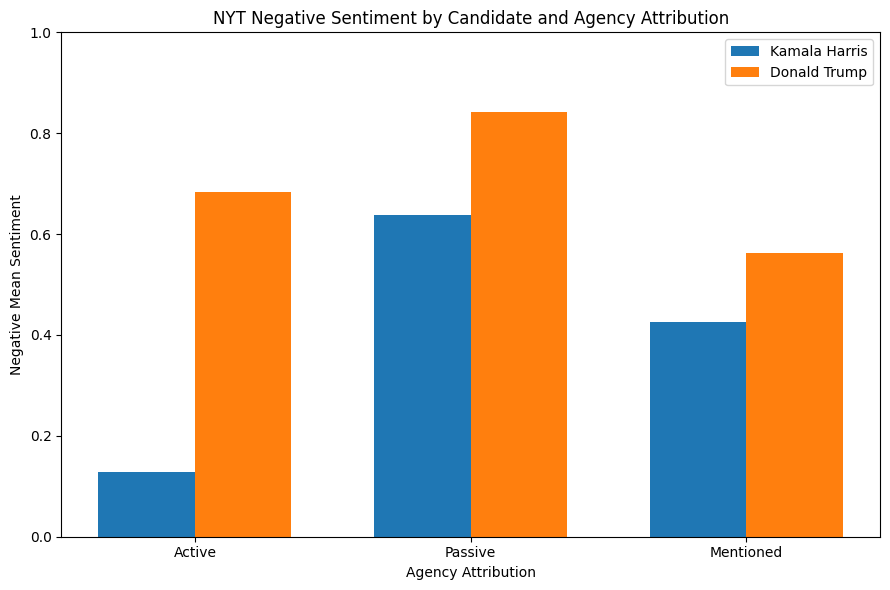

In [5]:
analysis_df = pl.read_csv("agency_results_checkpoint.csv")

agency_sentiment = (
    analysis_df
    .group_by(["agency", "agent"])
    .agg(
        pl.col("sentiment").mean().alias("mean_sentiment")
    )
)

agencies = ["active", "passive", "mentioned"]

# Convert negative sentiment to positive magnitude
harris = [
    -agency_sentiment.filter(
        (pl.col("agent") == "Kamala Harris") &
        (pl.col("agency") == agency)
    )["mean_sentiment"][0]
    for agency in agencies
]

trump = [
    -agency_sentiment.filter(
        (pl.col("agent") == "Donald Trump") &
        (pl.col("agency") == agency)
    )["mean_sentiment"][0]
    for agency in agencies
]

x = np.arange(len(agencies))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(x - width/2, harris, width, label="Kamala Harris")
plt.bar(x + width/2, trump, width, label="Donald Trump")

plt.xticks(x, ["Active", "Passive", "Mentioned"])

plt.xlabel("Agency Attribution")
plt.ylabel("Negative Mean Sentiment")
plt.title("NYT Negative Sentiment by Candidate and Agency Attribution")

plt.ylim(0, 1)

plt.legend()
plt.tight_layout()